In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix, hstack
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.layers import ReLU
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import pyhere

In [2]:
train_path = pyhere.here('Data', 'train_data.xlsx')
test_path = pyhere.here('Data', 'test_data.xlsx')
train_data = pd.read_excel(train_path)
test_data = pd.read_excel(test_path)
# Use dropna() to remove any rows with missing values
train_data = train_data.dropna()
test_data = test_data.dropna()
print(train_data.head())

            CountryName CountryCode  year  HDI_Index  \
0   Antigua and Barbuda         ATG  2022      0.848   
9   Antigua and Barbuda         ATG  2008      0.830   
10  Antigua and Barbuda         ATG  2009      0.827   
11  Antigua and Barbuda         ATG  2010      0.828   
12  Antigua and Barbuda         ATG  2011      0.828   

                   HDI_Category  FoodIndex  ElectricAccess  PopDensity  \
0   Very high human development      89.95           100.0  211.000000   
9   Very high human development     145.98           100.0  188.436364   
10  Very high human development     141.40            98.5  191.302273   
11  Very high human development     102.49            98.7  193.909091   
12  Very high human development     104.99            94.6  196.209091   

    PopInSlums  WaterStress  ...  IncomeGroup  YearlyChgInternet  \
0     2.646340     8.461538  ...  High income           0.997844   
9     2.646317     9.230769  ...  High income           3.164091   
10    2.646311

In [3]:
train_target = train_data['InternetUsersPct']
test_target = test_data['InternetUsersPct']

train_predictors = train_data.drop('InternetUsersPct', axis=1)
test_predictors = test_data.drop('InternetUsersPct', axis=1)

In [4]:
train_target = train_data['InternetUsersPct']
test_target = test_data['InternetUsersPct']

train_predictors = train_data.drop('InternetUsersPct', axis=1)
test_predictors = test_data.drop('InternetUsersPct', axis=1)

# Combine the predictor data frames to ensure consistent encoding
combined_predictors = pd.concat([train_predictors, test_predictors], ignore_index=True)

# Identify numerical and categorical columns
numerical_cols = combined_predictors.select_dtypes(include=np.number).columns
categorical_cols = combined_predictors.select_dtypes(include='object').columns

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Fit the scaler on the combined numerical data to learn the min/max values
combined_predictors[numerical_cols] = scaler.fit_transform(combined_predictors[numerical_cols])

# Initialize OneHotEncoder to create sparse output and handle unknown categories
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit the encoder on the combined data to learn all possible categories
combined_categorical_encoded = ohe.fit_transform(combined_predictors[categorical_cols])

# Combine the encoded categorical data with the numerical data
combined_features = np.concatenate([combined_predictors[numerical_cols].values, 
                                    combined_categorical_encoded], axis=1)

# Split the combined feature matrix back into training and test sets
train_features = combined_features[:len(train_predictors)]
test_features = combined_features[len(train_predictors):]




--- Training Model with Tanh and RMSProp---
Epoch 1/1000


C:\Users\barre\my_new_env2\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3.2290 - mae: 1.2480
Epoch 2/1000
50/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6117 - mae: 0.6238

C:\Users\barre\my_new_env2\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
C:\Users\barre\my_new_env2\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,mae
  current = self.get_monitor_value(logs)


71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5789 - mae: 0.6083
Epoch 3/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3725 - mae: 0.4755
Epoch 4/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3250 - mae: 0.4484
Epoch 5/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2873 - mae: 0.4297
Epoch 6/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2410 - mae: 0.3821
Epoch 7/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2252 - mae: 0.3696
Epoch 8/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2123 - mae: 0.3660
Epoch 9/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1687 - mae: 0.3201
Epoch 10/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1679 - mae: 0.3221
Epoch 11/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1515 - mae: 0.3005
Epoch 12/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1516 - mae: 0.3101
Epoch 13/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1386 - mae: 0.2886
Epoch 14/1000
71/71 ━━━━━━━━━━━━━━━━━

C:\Users\barre\my_new_env2\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0031 - mae: 0.0421 - val_loss: 0.0035 - val_mae: 0.0492
Epoch 2/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0029 - mae: 0.0414 - val_loss: 8.0025e-04 - val_mae: 0.0222
Epoch 3/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0033 - mae: 0.0428 - val_loss: 0.0010 - val_mae: 0.0249
Epoch 4/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0028 - mae: 0.0395 - val_loss: 0.0011 - val_mae: 0.0267
Epoch 5/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0028 - mae: 0.0402 - val_loss: 0.0040 - val_mae: 0.0535
Epoch 6/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0030 - mae: 0.0414 - val_loss: 0.0024 - val_mae: 0.0409
Epoch 7/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0026 - mae: 0.0364 - val_loss: 0.0010 - val_mae: 0.0253
Epoch 8/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0032 - mae: 0.0418 - val_loss: 0.0018 - val_mae: 0.0340
Epoch 9/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.003

C:\Users\barre\my_new_env2\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


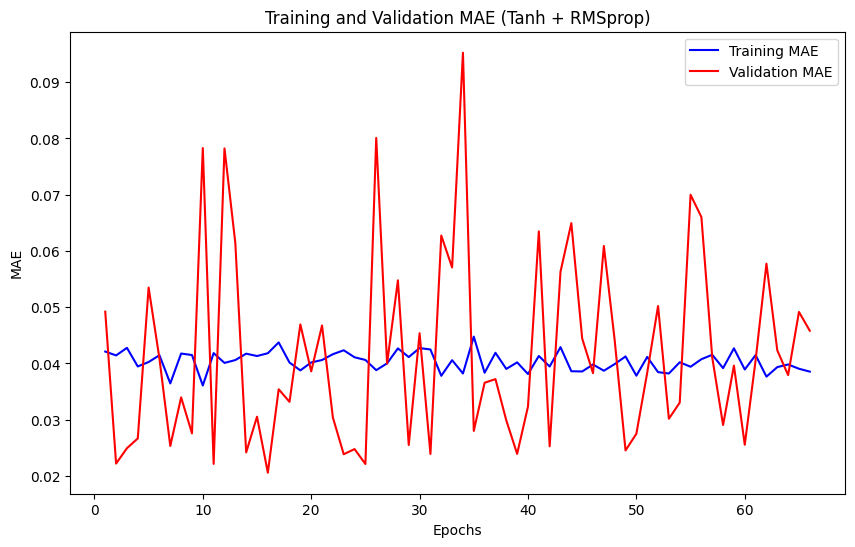

In [5]:
print("\n--- Training Model with Tanh and RMSProp---")
model_tanh_rms = Sequential()
model_tanh_rms.add(Dense(256, input_dim=train_features.shape[1], activation='tanh'))
model_tanh_rms.add(Dense(128, activation='tanh'))
model_tanh_rms.add(Dense(64, activation='tanh'))
model_tanh_rms.add(Dense(1, activation='linear'))

model_tanh_rms.compile(optimizer=RMSprop(learning_rate=0.001), loss="mse", metrics=["mae"])

# Define early stopping
early_stop_tanh = EarlyStopping(monitor='val_loss', patience=50, verbose=1, restore_best_weights=True)

model_tanh_rms.fit(train_features, train_target,
                    epochs=1000,
                    batch_size=32,
                    validation_data=(test_features, test_target),
                    callbacks=[early_stop_tanh],
                    verbose=1)

loss_tanh_rms =model_tanh_rms.evaluate(test_features, test_target, verbose=0)

history_tanh = model_tanh_rms.fit(train_features, train_target,
                    epochs=1000,
                    batch_size=32,
                    validation_split=0.2,
                    callbacks=[early_stop_tanh],
                    verbose=1)

tanh_results = model_tanh_rms.evaluate(test_features, test_target, verbose=0)
print("Raw evaluate results:", tanh_results)

# Plot the training and validation MAE
mae_tanh = history_tanh.history['mae']
val_mae_tanh = history_tanh.history['val_mae']
epochs = range(1, len(mae_tanh) + 1)
plt.figure(figsize=(10, 6))
plt.plot(epochs, mae_tanh, 'b', label='Training MAE')
plt.plot(epochs, val_mae_tanh, 'r', label='Validation MAE')
plt.title('Training and Validation MAE (Tanh + RMSprop)')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()




--- Training Model with Sigmoid and SGD ---
Epoch 1/1000


C:\Users\barre\my_new_env2\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 15.1651 - mae: 3.3292
Epoch 2/1000
55/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10.3761 - mae: 2.7964

C:\Users\barre\my_new_env2\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
C:\Users\barre\my_new_env2\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,mae
  current = self.get_monitor_value(logs)


71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 10.6324 - mae: 2.8550
Epoch 3/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 10.5323 - mae: 2.8404
Epoch 4/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 10.4174 - mae: 2.8201
Epoch 5/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 10.3060 - mae: 2.8103
Epoch 6/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 10.1772 - mae: 2.7919
Epoch 7/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 10.0349 - mae: 2.7676
Epoch 8/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.8616 - mae: 2.7496
Epoch 9/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.6770 - mae: 2.7188
Epoch 10/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9.4447 - mae: 2.6902
Epoch 11/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.1716 - mae: 2.6470
Epoch 12/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.8422 - mae: 2.5994
Epoch 13/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.4373 - mae: 2.5440
Epoch 14/1000
71/71 ━━━━━━━━━━━

C:\Users\barre\my_new_env2\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0416 - mae: 0.1489 - val_loss: 0.0404 - val_mae: 0.1511
Epoch 2/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0415 - mae: 0.1498 - val_loss: 0.0411 - val_mae: 0.1498
Epoch 3/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0414 - mae: 0.1491 - val_loss: 0.0408 - val_mae: 0.1496
Epoch 4/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0416 - mae: 0.1491 - val_loss: 0.0405 - val_mae: 0.1496
Epoch 5/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0416 - mae: 0.1492 - val_loss: 0.0405 - val_mae: 0.1498
Epoch 6/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0415 - mae: 0.1493 - val_loss: 0.0408 - val_mae: 0.1498
Epoch 7/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0414 - mae: 0.1490 - val_loss: 0.0405 - val_mae: 0.1500
Epoch 8/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0414 - mae: 0.1490 - val_loss: 0.0405 - val_mae: 0.1504
Epoch 9/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0415 - 

C:\Users\barre\my_new_env2\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


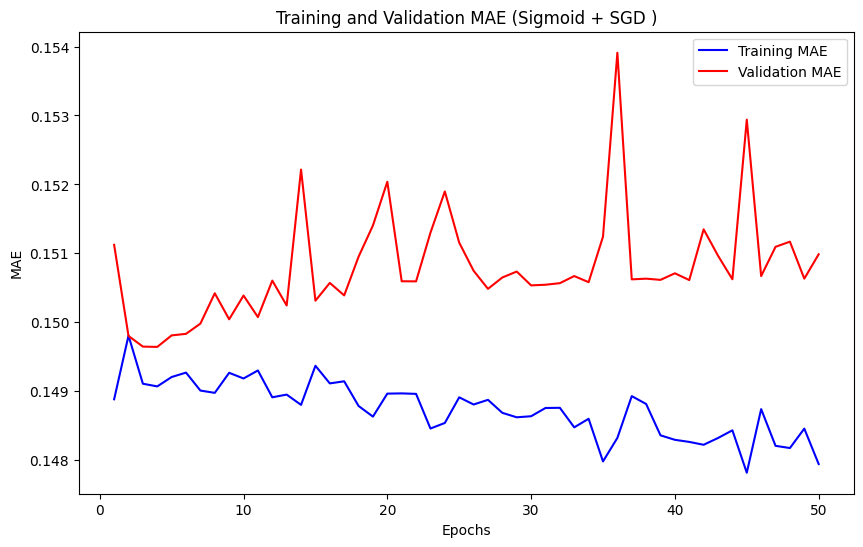

In [6]:
print("\n--- Training Model with Sigmoid and SGD ---")
model_sig = Sequential()
model_sig.add(Dense(256, input_dim=train_features.shape[1], activation='tanh'))
model_sig.add(Dense(128, activation='sigmoid'))
model_sig.add(Dense(64, activation='sigmoid'))
model_sig.add(Dense(1, activation='linear'))

model_sig.compile(optimizer=SGD(learning_rate=0.001), loss="mse", metrics=["mae"])

# Define early stopping
early_stop_sig = EarlyStopping(monitor='val_loss', patience=50, verbose=1, restore_best_weights=True)

model_sig.fit(train_features, train_target,
                    epochs=1000,
                    batch_size=32,
                    validation_data=(test_features, test_target),
                    callbacks=[early_stop_tanh],
                    verbose=1)

loss_sig = model_sig.evaluate(test_features, test_target, verbose=0)

history_sig = model_sig.fit(train_features, train_target,
                    epochs=1000,
                    batch_size=32,
                    validation_split=0.2,
                    callbacks=[early_stop_tanh],
                    verbose=1)

sig_results = model_sig.evaluate(test_features, test_target, verbose=0)
print("Raw evaluate results:", sig_results)

# Plot the training and validation MAE
mae_sig = history_sig.history['mae']
val_mae_sig = history_sig.history['val_mae']
epochs = range(1, len(mae_sig) + 1)
plt.figure(figsize=(10, 6))
plt.plot(epochs, mae_sig, 'b', label='Training MAE')
plt.plot(epochs, val_mae_sig, 'r', label='Validation MAE')
plt.title('Training and Validation MAE (Sigmoid + SGD )')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

C:\Users\barre\my_new_env2\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Training Model with ReLu and Adam ---
Epoch 1/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 8.4954 - mae: 2.0538 
Epoch 2/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6219 - mae: 0.6007

C:\Users\barre\my_new_env2\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
C:\Users\barre\my_new_env2\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,mae
  current = self.get_monitor_value(logs)


71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3666 - mae: 0.4480
Epoch 3/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1182 - mae: 0.2645
Epoch 4/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0839 - mae: 0.2216
Epoch 5/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0705 - mae: 0.2012
Epoch 6/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0614 - mae: 0.1882
Epoch 7/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0576 - mae: 0.1810
Epoch 8/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0528 - mae: 0.1722
Epoch 9/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0552 - mae: 0.1769
Epoch 10/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0482 - mae: 0.1637
Epoch 11/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0427 - mae: 0.1543
Epoch 12/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0428 - mae: 0.1559
Epoch 13/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0399 - mae: 0.1473
Epoch 14/1000
71/71 ━━━━━━━━━━━━━━━━━

C:\Users\barre\my_new_env2\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.8728e-04 - mae: 0.0230 - val_loss: 9.1117e-04 - val_mae: 0.0239
Epoch 2/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.8951e-04 - mae: 0.0216 - val_loss: 8.3138e-04 - val_mae: 0.0218
Epoch 3/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.6965e-04 - mae: 0.0216 - val_loss: 8.4899e-04 - val_mae: 0.0225
Epoch 4/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0012 - mae: 0.0261 - val_loss: 0.0011 - val_mae: 0.0250
Epoch 5/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0011 - mae: 0.0261 - val_loss: 8.2354e-04 - val_mae: 0.0218
Epoch 6/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0013 - mae: 0.0283 - val_loss: 7.6647e-04 - val_mae: 0.0210
Epoch 7/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9.1730e-04 - mae: 0.0235 - val_loss: 0.0015 - val_mae: 0.0301
Epoch 8/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0636e-04 - mae: 0.0188 - val_loss: 8.9567e-04 - val_mae: 0.0234
Epoch 9/1000
57/57 ━━━━━━

C:\Users\barre\my_new_env2\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


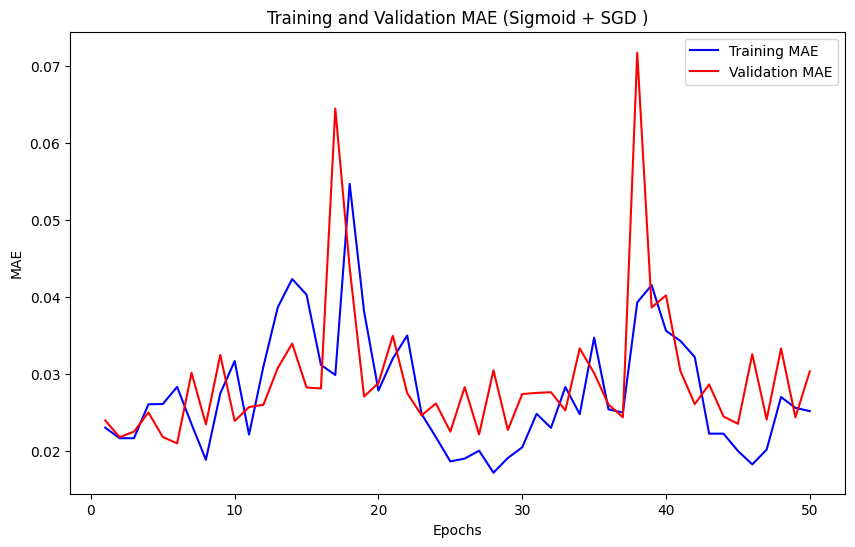

In [7]:
print("\n--- Training Model with ReLu and Adam ---")
model_relu = Sequential()
model_relu.add(Dense(256, input_dim=train_features.shape[1], activation='relu'))
model_relu.add(Dense(128, activation='relu'))
model_relu.add(Dense(64, activation='relu'))
model_relu.add(Dense(1, activation='linear'))

model_relu.compile(optimizer=Adam(learning_rate=0.001), loss="mse", metrics=["mae"])

# Define early stopping
early_stop_relu = EarlyStopping(monitor='val_loss', patience=50, verbose=1, restore_best_weights=True)

model_relu.fit(train_features, train_target,
                    epochs=1000,
                    batch_size=32,
                    validation_data=(test_features, test_target),
                    callbacks=[early_stop_tanh],
                    verbose=1)

loss_relu = model_relu.evaluate(test_features, test_target, verbose=0)

history_relu = model_relu.fit(train_features, train_target,
                    epochs=1000,
                    batch_size=32,
                    validation_split=0.2,
                    callbacks=[early_stop_tanh],
                    verbose=1)

relu_results = model_relu.evaluate(test_features, test_target, verbose=0)
print("Raw evaluate results:", relu_results)

# Plot the training and validation MAE
mae_relu = history_relu.history['mae']
val_mae_relu = history_relu.history['val_mae']
epochs = range(1, len(mae_relu) + 1)
plt.figure(figsize=(10, 6))
plt.plot(epochs, mae_relu, 'b', label='Training MAE')
plt.plot(epochs, val_mae_relu, 'r', label='Validation MAE')
plt.title('Training and Validation MAE (Sigmoid + SGD )')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

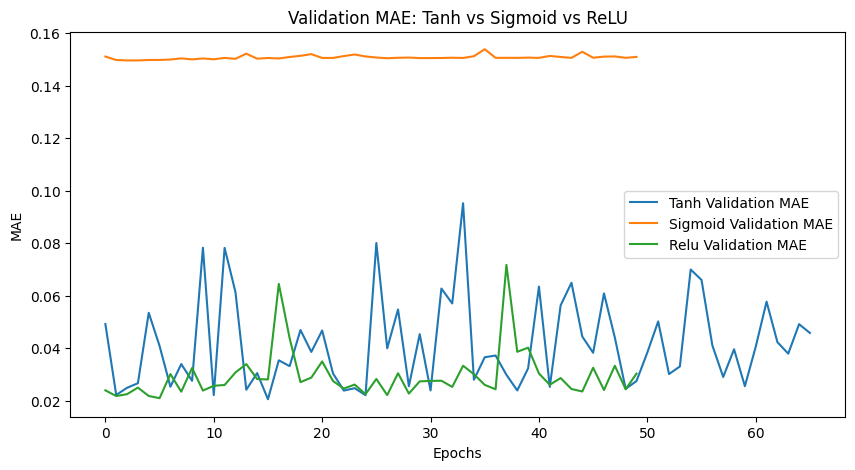

In [8]:
plt.figure(figsize=(10,5))
plt.plot(history_tanh.history['val_mae'], label="Tanh Validation MAE")
plt.plot(history_sig.history['val_mae'], label="Sigmoid Validation MAE")
plt.plot(history_relu.history['val_mae'], label="Relu Validation MAE")
plt.title("Validation MAE: Tanh vs Sigmoid vs ReLU")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()
plt.show()